In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('orders.csv')

In [4]:
#understand what you are looking at

In [5]:
df.shape

(60, 6)

In [6]:
df.columns

Index(['order_id', 'user_id', 'order_month', 'category', 'amount', 'location'], dtype='str')

In [7]:
df.dtypes

order_id         int64
user_id          int64
order_month        str
category           str
amount         float64
location           str
dtype: object

In [8]:
df.head(10)

,order_id,user_id,order_month,category,amount,location
0,1001,52,March,Sports,265.16,France
1,1002,93,April,Beauty,220.36,UK
2,1003,15,March,Electronics,126.61,Germany
3,1004,72,April,Electronics,77.54,Spain
4,1005,61,January,Beauty,182.06,Spain
5,1006,21,April,Grocery,472.60,Morocco
6,1007,83,March,Grocery,175.14,UK
7,1008,87,March,Beauty,269.02,UK
8,1009,75,February,Electronics,357.45,Morocco
9,1010,75,January,Fashion,194.54,Morocco


In [9]:
df.describe()

,order_id,user_id,amount
count,60.000000,60.000000,60.000000
mean,1030.500000,50.116667,246.654500
std,17.464249,29.406613,134.721376
min,1001.000000,2.000000,27.960000
25%,1015.750000,21.750000,135.890000
50%,1030.500000,54.000000,256.810000
75%,1045.250000,75.000000,343.280000
max,1060.000000,93.000000,493.110000


In [10]:
df

,order_id,user_id,order_month,category,amount,location
0,1001,52,March,Sports,265.16,France
1,1002,93,April,Beauty,220.36,UK
2,1003,15,March,Electronics,126.61,Germany
3,1004,72,April,Electronics,77.54,Spain
4,1005,61,January,Beauty,182.06,Spain
5,1006,21,April,Grocery,472.60,Morocco
6,1007,83,March,Grocery,175.14,UK
7,1008,87,March,Beauty,269.02,UK
8,1009,75,February,Electronics,357.45,Morocco
9,1010,75,January,Fashion,194.54,Morocco


In [12]:
df.isnull().sum()

order_id       0
user_id        0
order_month    0
category       0
amount         0
location       0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [17]:
df[df['amount'] <= 0]

,order_id,user_id,order_month,category,amount,location


In [18]:
# Q1: Revenue by category: Which product category brings in the most money? 
# Why it matters: tells management where to focus marketing budget or inventory.

In [28]:
df.groupby('category')['amount'].sum().sort_values(ascending=False)

category
Electronics    4570.73
Beauty         3900.96
Fashion        3327.68
Grocery        2405.60
Sports          594.30
Name: amount, dtype: float64

In [29]:
#The top row is your answer to “which category brings in the most revenue.”

In [30]:
# Q2 : Revenue by location: Which country is the strongest market?
# Why it matters: informs where to expand or where to invest in local marketing.

In [31]:
df.groupby('location')['amount'].sum().sort_values(ascending=False)

location
UK         4706.67
Morocco    3663.38
Germany    3326.06
Spain      1670.72
France     1432.44
Name: amount, dtype: float64

In [37]:
df.groupby('location')['amount'].agg(['sum','mean','count'])

,sum,mean,count
location,,,
France,1432.44,286.488000,5
Germany,3326.06,237.575714,14
Morocco,3663.38,228.961250,16
Spain,1670.72,185.635556,9
UK,4706.67,294.166875,16


In [35]:
df.groupby('category')['amount'].mean().sort_values(ascending=False)

category
Grocery        267.288889
Electronics    253.929444
Beauty         243.810000
Fashion        237.691429
Sports         198.100000
Name: amount, dtype: float64

In [60]:
month_order = ['January', 'February', 'March', 'April']

In [61]:
monthly = df.groupby('order_month')['amount'].sum().reindex(month_order)

In [86]:
monthly

order_month
January     4148.24
February    3941.59
March       2578.97
April       4130.47
Name: amount, dtype: float64

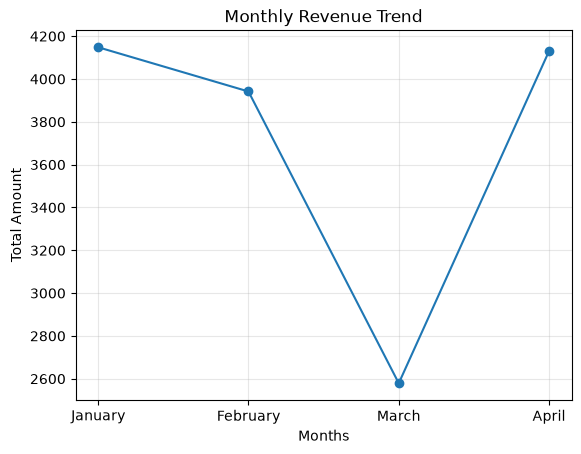

In [89]:
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Amount')
plt.xlabel('Months')
plt.grid(alpha=0.3)
plt.plot(monthly.index, monthly.values, marker = 'o')
plt.show()

In [91]:
top_users = df.groupby('user_id')['amount'].sum().sort_values(ascending = False)

In [93]:
top_users.head(10)

user_id
60    854.53
21    711.29
62    634.49
2     613.70
92    597.74
75    551.99
89    526.34
88    524.17
53    501.21
58    493.11
Name: amount, dtype: float64

In [94]:
# What % of total revenue do the top 10 users represent?

In [100]:
top10_share = top_users.head(10).sum() / df['amount'].sum() * 100

In [101]:
top10_share

np.float64(40.60044853563723)

In [113]:
df.pivot_table(
    values = 'amount',
    index = 'category',
    columns = 'location',
    aggfunc = 'sum',
    fill_value = 0
)

location,France,Germany,Morocco,Spain,UK
category,,,,,
Beauty,582.66,1061.71,128.72,360.23,1767.64
Electronics,0.00,1378.20,1523.30,422.77,1246.46
Fashion,0.00,573.56,948.33,752.73,1053.06
Grocery,584.62,312.59,733.89,134.99,639.51
Sports,265.16,0.00,329.14,0.00,0.00


In [115]:
#khasni nfhm had etap mzn chni kiw93 bdapt wch kit groupaw b groupby() ?

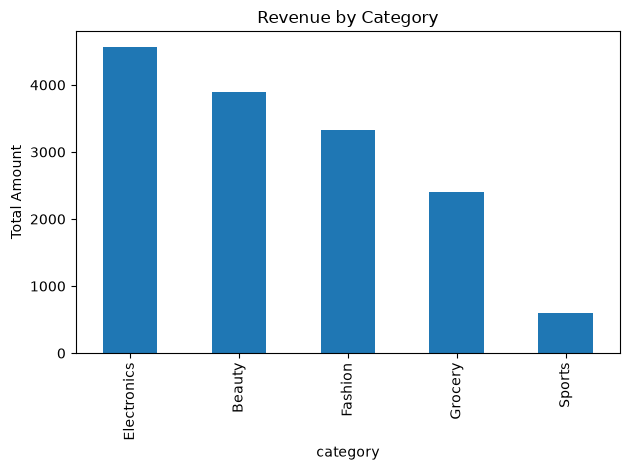

In [118]:
df.groupby('category')['amount'].sum().sort_values(ascending=False).plot(kind='bar',title='Revenue by Category')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()